# Facial Emotions Recognition System

##  Importing the Libraries

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O 
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.losses import categorical_crossentropy
from sklearn.metrics import accuracy_score
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix


## Loading the Dataset

In [3]:
# Path to the directory
data= pd.read_csv('D:\\Minor2_FERSystem\\Dataset\\fer2013.csv')

## Dataset Overview

In [4]:
data.shape

(35887, 3)

In [5]:
data.isnull().sum()

emotion    0
pixels     0
Usage      0
dtype: int64

In [6]:
# first 5 row of data
data.head(5)

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [7]:
#check usage values
#80% training, 10% validation and 10% test
data.Usage.value_counts()

Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64

In [8]:
#check target labels
emotion_map= {0:'Angry', 1:'Digust',2: 'Fear', 3:'Happy', 4:'Sad', 5:'Surprise', 6:'Neutral'}
emotion_counts = data['emotion'].value_counts(sort=False).reset_index()
emotion_counts.columns =['emotion', 'number']
emotion_counts['emotion']= emotion_counts['emotion'].map(emotion_map)
emotion_counts

,emotion,number
0,Angry,4953
1,Fear,5121
2,Sad,6077
3,Neutral,6198
4,Happy,8989
5,Surprise,4002
6,Digust,547


## Data Analysis (Graphical Representation)

###  BarGraph

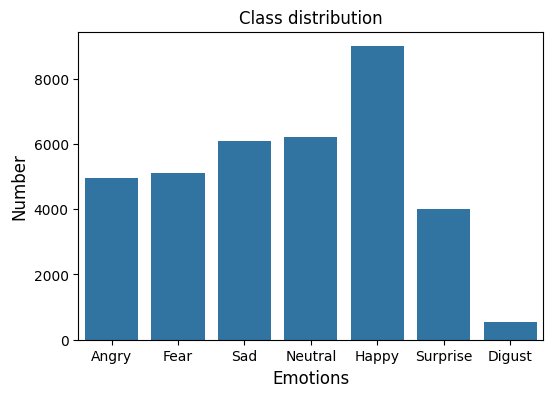

In [9]:
# Plotting a bar graph
plt.figure(figsize=(6,4))
sns.barplot(x=emotion_counts.emotion, y=emotion_counts.number)
plt.title('Class distribution')
plt.ylabel('Number', fontsize=12)
plt.xlabel('Emotions', fontsize=12)
plt.show()

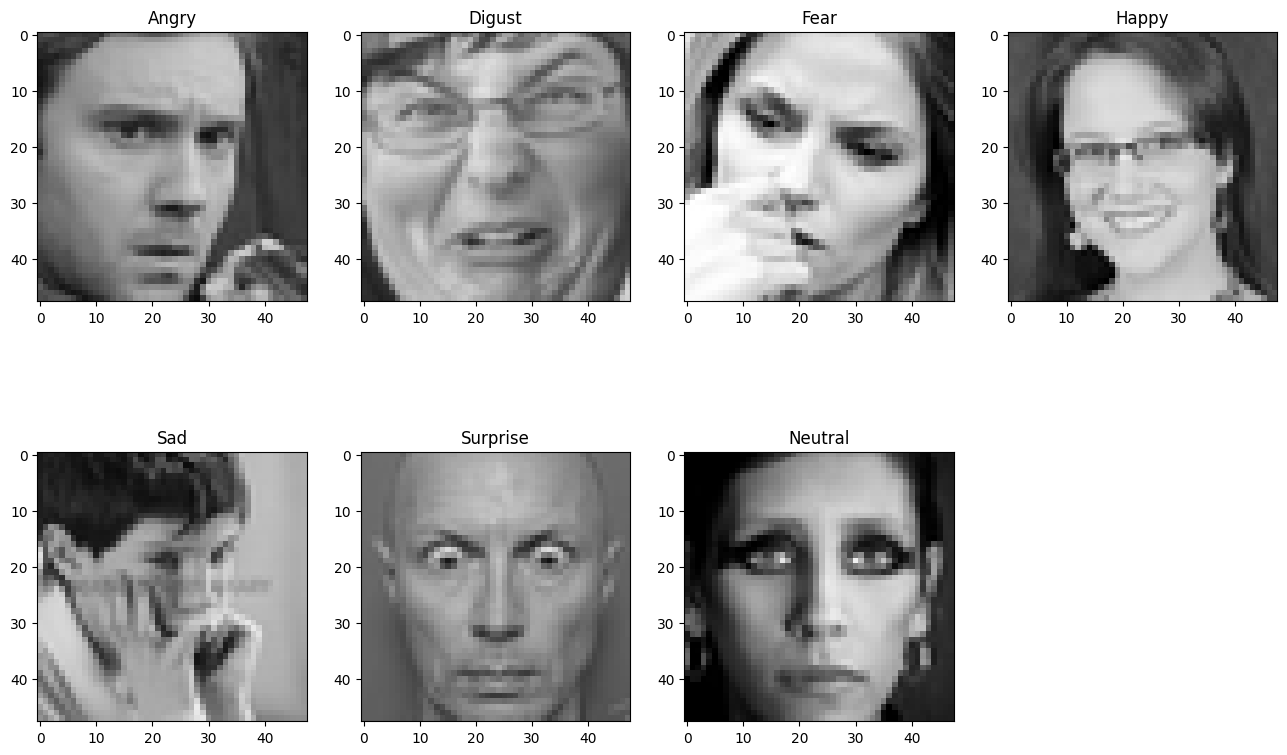

In [10]:
def row2image(row):
    pixels, emotion = row['pixels'], emotion_map[row['emotion']]
    img= np.array(pixels.split(), dtype='float32')
    img= img.reshape(48,48)
    image =np.zeros((48,48,3))
    image[:,:,0]= img
    image[:,:,1]= img
    image[:,:,2]= img
    return image.astype(np.uint8), emotion

plt.figure(0, figsize=(16,10))
for i in range(1,8):
    face = data[data['emotion']==i-1].iloc[0]
    img, label =row2image(face)
    plt.subplot(2,4,i)
    plt.imshow(img)
    plt.title(label)

plt.show()

## Pre-processing data

### Shuffling the data

In [11]:
data= data.sample(frac=1)

### One Hot Encoding

In [12]:
labels= to_categorical(data[['emotion']],num_classes=7)

In [13]:
#Changing image pixels to Numpy array
train_pixels = data["pixels"].astype(str).str.split(" ").tolist()
train_pixels = np.uint8(train_pixels)

###  Standardization

In [14]:
# StandartScaler() function takes only 2 dimensional array as i/p,
# we reshape the data then apply our scaler to make the mean zero and standart deviation as unit.
pixels = train_pixels.reshape((35887*2304,1))

In [15]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
pixels =scaler.fit_transform(pixels)

### Reshaping the data (48,48)

In [16]:
pixels= train_pixels.reshape((35887, 48, 48,1))

### Train test validation split

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(pixels, labels, test_size=0.1, shuffle=False)
X_train, X_val, y_train, y_val= train_test_split(X_train, y_train, test_size=0.1, shuffle=False)

In [18]:
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(29068, 48, 48, 1)
(3589, 48, 48, 1)
(3230, 48, 48, 1)


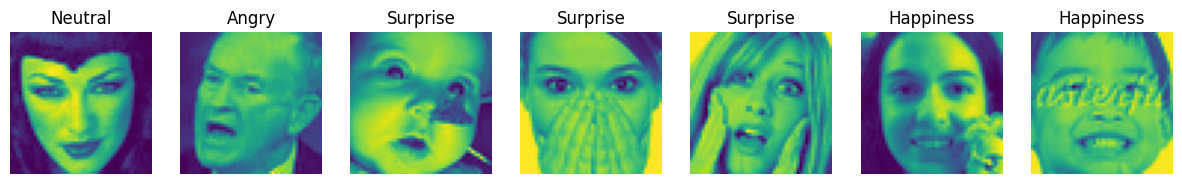

In [19]:
# train data contains one sample of each class.
plt.figure(figsize=(15,23))
label_dict= {0:'Angry', 1:'Disgust', 2:'Fear', 3 :'Happiness', 4: 'Sad', 5: 'Surprise', 6:'Neutral'}
i= 1
for i in range (7):
    img=np.squeeze(X_train[i])
    plt.subplot(1,7,i+1)
    plt.imshow(img)
    index= np.argmax(y_train[i])
    plt.title(label_dict[index])
    plt.axis('off')
    i+= 1
plt.show()

## Data augmentation using ImageDataGenerator

In [20]:
datagen= ImageDataGenerator(width_shift_range= 0.1,
                               height_shift_range=0.1,
                               horizontal_flip=True,
                               zoom_range=0.2)
valgen= ImageDataGenerator(width_shift_range= 0.1,
                               height_shift_range =0.1,
                               horizontal_flip=True,
                               zoom_range=0.2)

In [21]:
datagen.fit(X_train)
valgen.fit(X_val)

In [22]:
train_generator= datagen.flow(X_train, y_train, batch_size=64)
val_generator= datagen.flow(X_val, y_val, batch_size=64)

## Building CNN Model

### Designing a model

In [23]:
def cnn_model():

  model= tf.keras.models.Sequential()
  model.add(Input(shape=(48,48,1)))

  model.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu'))
  model.add(Conv2D(64,(3,3), padding='same', activation='relu' ))
  model.add(BatchNormalization())
  model.add(MaxPool2D(pool_size=(2, 2)))
  model.add(Dropout(0.25))

  model.add(Conv2D(128,(3,3), padding='same', activation='relu'))
  model.add(BatchNormalization())
  model.add(MaxPool2D(pool_size=(2, 2)))
  model.add(Dropout(0.25))

  model.add(Conv2D(256,(3,3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.01)))
  model.add(BatchNormalization())
  model.add(MaxPool2D(pool_size=(2, 2)))
  model.add(Dropout(0.25))

  model.add(Flatten())
  model.add(Dense(256,activation = 'relu'))
  model.add(BatchNormalization())
  model.add(Dropout(0.4))

  model.add(Dense(7, activation='softmax'))
  model.compile(
    optimizer= Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy'])
  return model

In [24]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten,Dense,Dropout,BatchNormalization,MaxPooling2D,Activation,Input
from tensorflow.keras import regularizers
model= cnn_model()

In [25]:
model.compile(
    optimizer= Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,752,007 (10.50 MB)

 Trainable params: 2,750,599 (10.49 MB)

 Non-trainable params: 1,408 (5.50 KB)

## Early stopping

Adding checkpointer to implement Early Stopping to prevent overfitting.

In [30]:
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping
checkpointer = [EarlyStopping(monitor= 'val_accuracy', verbose=1,
                              restore_best_weights=True,mode="max",patience= 5),
                ModelCheckpoint('best_model.h5',monitor="val_accuracy",verbose=1,
                                save_best_only=True,mode="max")]

In [31]:
history = model.fit(train_generator,
                    epochs=15,
                    batch_size=64,
                    verbose=1,
                    callbacks=checkpointer,
                    validation_data=val_generator)

Epoch 1/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.1926 - loss: 4.2375
Epoch 1: val_accuracy improved from None to 0.29319, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 217s 467ms/step - accuracy: 0.2183 - loss: 3.9952 - val_accuracy: 0.2932 - val_loss: 3.4665
Epoch 2/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.2666 - loss: 3.6034
Epoch 2: val_accuracy improved from 0.29319 to 0.32074, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 225s 495ms/step - accuracy: 0.2814 - loss: 3.5146 - val_accuracy: 0.3207 - val_loss: 3.3012
Epoch 3/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.2980 - loss: 3.2788
Epoch 3: val_accuracy improved from 0.32074 to 0.35263, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 275s 604ms/step - accuracy: 0.3095 - loss: 3.1977 - val_accuracy: 0.3526 - val_loss: 2.8558
Epoch 4/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.3388 - loss: 2.9531
Epoch 4: val_accuracy improved from 0.35263 to 0.35604, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 225s 494ms/step - accuracy: 0.3424 - loss: 2.8787 - val_accuracy: 0.3560 - val_loss: 2.8458
Epoch 5/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.3544 - loss: 2.6786
Epoch 5: val_accuracy improved from 0.35604 to 0.38297, saving model to best_model.h5


...


Epoch 9: finished saving model to best_model.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 159s 350ms/step - accuracy: 0.4467 - loss: 1.8831 - val_accuracy: 0.4851 - val_loss: 1.7062
Epoch 10/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.4581 - loss: 1.7952
Epoch 10: val_accuracy did not improve from 0.48514
455/455 ━━━━━━━━━━━━━━━━━━━━ 156s 342ms/step - accuracy: 0.4579 - loss: 1.7765 - val_accuracy: 0.4669 - val_loss: 1.7845
Epoch 11/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.4805 - loss: 1.6909
Epoch 11: val_accuracy improved from 0.48514 to 0.48731, saving model to best_model.h5



Epoch 11: finished saving model to best_model.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 166s 366ms/step - accuracy: 0.4748 - loss: 1.6902 - val_accuracy: 0.4873 - val_loss: 1.6182
Epoch 12/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.4777 - loss: 1.6454
Epoch 12: val_accuracy improved from 0.48731 to 0.49598, saving model to best_model.h5



Epoch 12: finished saving model to best_model.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 156s 343ms/step - accuracy: 0.4836 - loss: 1.6200 - val_accuracy: 0.4960 - val_loss: 1.5381
Epoch 13/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.4874 - loss: 1.5803
Epoch 13: val_accuracy improved from 0.49598 to 0.51889, saving model to best_model.h5



Epoch 13: finished saving model to best_model.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 156s 342ms/step - accuracy: 0.4915 - loss: 1.5614 - val_accuracy: 0.5189 - val_loss: 1.4979
Epoch 14/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.5034 - loss: 1.5098
Epoch 14: val_accuracy did not improve from 0.51889
455/455 ━━━━━━━━━━━━━━━━━━━━ 157s 344ms/step - accuracy: 0.5031 - loss: 1.5016 - val_accuracy: 0.5173 - val_loss: 1.4860
Epoch 15/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.5183 - loss: 1.4629
Epoch 15: val_accuracy improved from 0.51889 to 0.52012, saving model to best_model.h5



Epoch 15: finished saving model to best_model.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 161s 354ms/step - accuracy: 0.5130 - loss: 1.4630 - val_accuracy: 0.5201 - val_loss: 1.4247
Restoring model weights from the end of the best epoch: 15.


## Visualizing Results

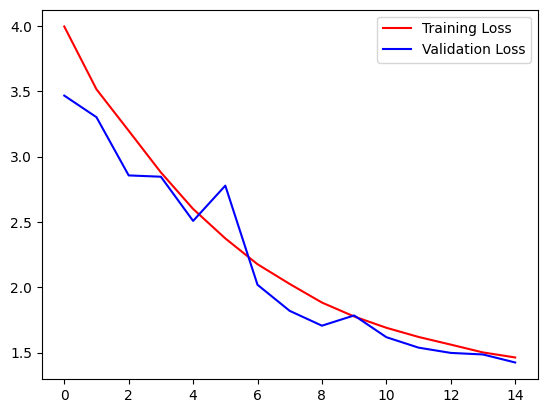

In [32]:
plt.plot(history.history["loss"],'r', label="Training Loss")
plt.plot(history.history["val_loss"],'b', label="Validation Loss")
plt.legend()

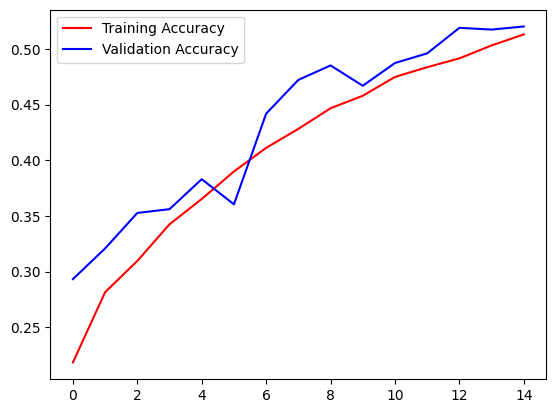

In [33]:
plt.plot(history.history["accuracy"],'r',label="Training Accuracy")
plt.plot(history.history["val_accuracy"],'b',label="Validation Accuracy")
plt.legend()

In [34]:
loss= model.evaluate(X_test,y_test)
print("Test Acc: " + str(loss[1]))

113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.5745 - loss: 1.3172
Test Acc: 0.5745332837104797


In [35]:
preds= model.predict(X_test)
y_pred=np.argmax(preds , axis = 1 )

113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step


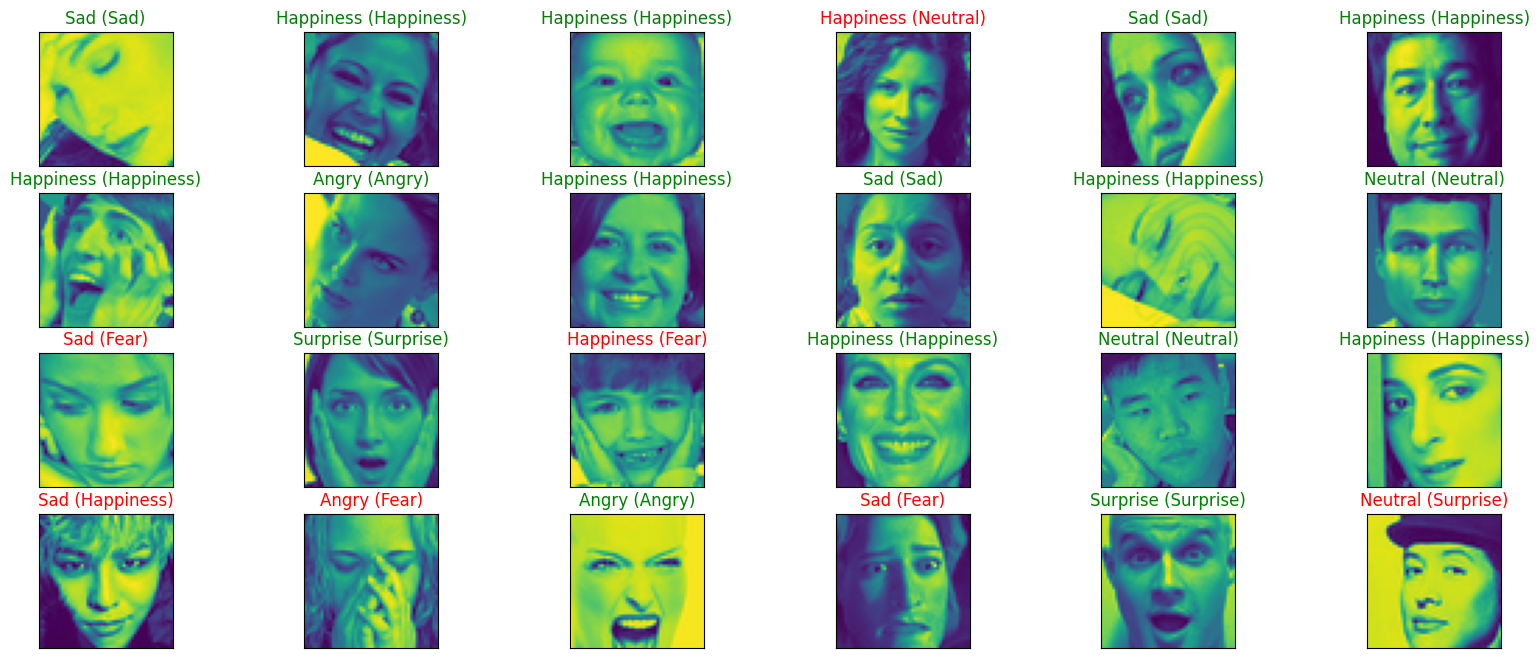

In [36]:
label_dict= {0 :'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happiness', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

figure= plt.figure(figsize=(20, 8))
for i, index in enumerate(np.random.choice(X_test.shape[0], size=24, replace=False)):
    ax=figure.add_subplot(4, 6, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(X_test[index]))
    predict_index=label_dict[(y_pred[index])]
    true_index =label_dict[np.argmax(y_test,axis=1)[index]]

    ax.set_title("{} ({})".format((predict_index),
                                  (true_index)),
                                  color=("green" if predict_index==true_index else "red"))

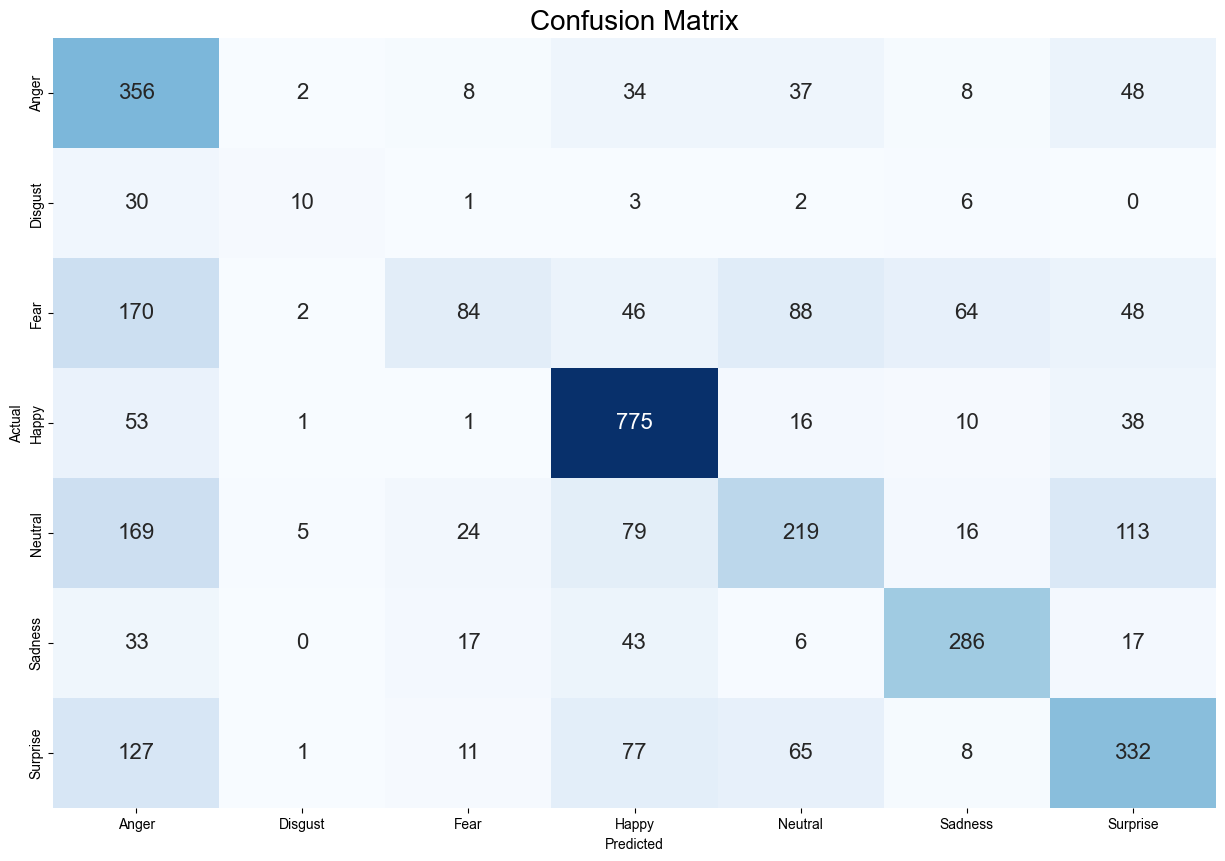

In [37]:
CLASS_LABELS= ['Anger', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sadness', "Surprise"]

cm_data= confusion_matrix(np.argmax(y_test, axis = 1 ), y_pred)
cm=pd.DataFrame(cm_data, columns=CLASS_LABELS, index = CLASS_LABELS)
cm.index.name='Actual'
cm.columns.name='Predicted'
plt.figure(figsize=(15,10))
plt.title('Confusion Matrix',fontsize = 20)
sns.set(font_scale=1.2)
ax = sns.heatmap(cm, cbar=False, cmap="Blues", annot=True, annot_kws={"size": 16}, fmt='g')

In [38]:
from sklearn.metrics import classification_report
print(classification_report(np.argmax(y_test, axis= 1 ),y_pred,digits=3))

              precision    recall  f1-score   support

           0      0.380     0.722     0.498       493
           1      0.476     0.192     0.274        52
           2      0.575     0.167     0.259       502
           3      0.733     0.867     0.794       894
           4      0.506     0.350     0.414       625
           5      0.719     0.711     0.715       402
           6      0.557     0.535     0.546       621

    accuracy                          0.575      3589
   macro avg      0.564     0.506     0.500      3589
weighted avg      0.587     0.575     0.553      3589



## Saving the Model

In [39]:
#import pickle library
import pickle
filename='model.h5'
pickle.dump(history,open(filename,'wb'))